<a href="https://colab.research.google.com/github/Okohfrank/SortAI/blob/main/AI_Controlled_Pneumatic_Waste_Sorting_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"osaigiefrank","key":"efd28ded15284466521661930a73c87a"}'}

In [2]:
import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("/content/kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

print("Kaggle API ready")

Kaggle API ready


In [3]:
!kaggle datasets download -d techsash/waste-classification-data

import zipfile
with zipfile.ZipFile("waste-classification-data.zip", "r") as zip_ref:
    zip_ref.extractall("/content/waste_data")

print("Dataset ready")

Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data
License(s): CC-BY-SA-4.0
100% 427M/427M [00:26<00:00, 16.7MB/s]

Dataset ready


In [4]:
import os

for split in ["TRAIN", "TEST"]:
    path = f"/content/waste_data/DATASET/{split}"
    classes = os.listdir(path)
    print(f"\n{split} classes: {classes}")
    for cls in classes:
        count = len(os.listdir(f"{path}/{cls}"))
        print(f"  {cls}: {count} images")


TRAIN classes: ['O', 'R']
  O: 12565 images
  R: 9999 images

TEST classes: ['O', 'R']
  O: 1401 images
  R: 1112 images


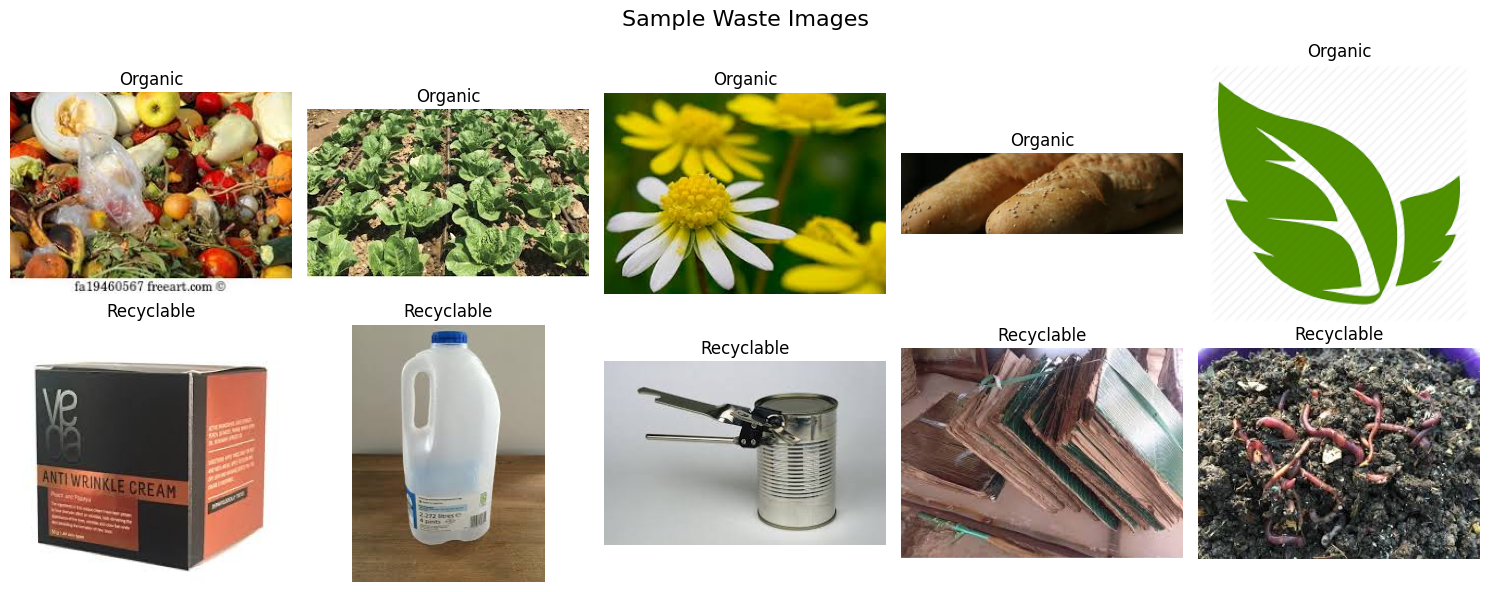

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Waste Images", fontsize=16)

for i, cls in enumerate(['O', 'R']):
    folder = f"/content/waste_data/DATASET/TRAIN/{cls}"
    images = random.sample(os.listdir(folder), 5)
    for j, img_name in enumerate(images):
        img = mpimg.imread(f"{folder}/{img_name}")
        axes[i][j].imshow(img)
        axes[i][j].axis('off')
        axes[i][j].set_title("Organic" if cls == 'O' else "Recyclable")

plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    "/content/waste_data/DATASET/TRAIN",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)


val_gen = train_datagen.flow_from_directory(
    "/content/waste_data/DATASET/TRAIN",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


test_gen = test_datagen.flow_from_directory(
    "/content/waste_data/DATASET/TEST",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples: {test_gen.samples}")
print(f"Class mapping: {train_gen.class_indices}")

Found 20309 images belonging to 2 classes.
Found 2255 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Training samples: 20309
Validation samples: 2255
Test samples: 2513
Class mapping: {'O': 0, 'R': 1}


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam


base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)


base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)


checkpoint = ModelCheckpoint(
    "best_waste_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)


history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

print("\nTraining complete")

Epoch 1/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 316s 467ms/step - accuracy: 0.8703 - loss: 0.3090 - val_accuracy: 0.9317 - val_loss: 0.1783
Epoch 2/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 263s 414ms/step - accuracy: 0.9187 - loss: 0.2162 - val_accuracy: 0.9344 - val_loss: 0.1744
Epoch 3/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 263s 414ms/step - accuracy: 0.9222 - loss: 0.2018 - val_accuracy: 0.9441 - val_loss: 0.1503
Epoch 4/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 260s 410ms/step - accuracy: 0.9268 - loss: 0.1921 - val_accuracy: 0.9463 - val_loss: 0.1466
Epoch 5/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 252s 397ms/step - accuracy: 0.9294 - loss: 0.1837 - val_accuracy: 0.9463 - val_loss: 0.1441
Epoch 6/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 258s 406ms/step - accuracy: 0.9339 - loss: 0.1736 - val_accuracy: 0.9503 - val_loss: 0.1330
Epoch 7/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 253s 399ms/step - accuracy: 0.9361 - loss: 0.1699 - val_accuracy: 0.9508 - val_loss: 0.1300
Epoch 8/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 253s 398ms/step - accuracy: 0.9385 -

In [9]:
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.8735 - loss: 0.2851

Test Accuracy: 87.35%
Test Loss: 0.2851


79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step


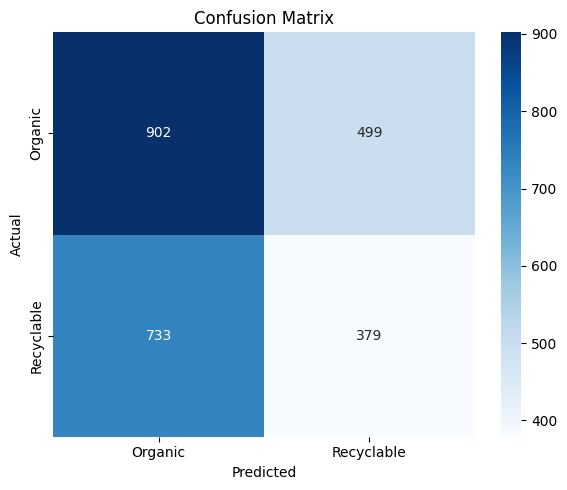


Classification Report:
              precision    recall  f1-score   support

     Organic       0.55      0.64      0.59      1401
  Recyclable       0.43      0.34      0.38      1112

    accuracy                           0.51      2513
   macro avg       0.49      0.49      0.49      2513
weighted avg       0.50      0.51      0.50      2513



In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
preds = model.predict(test_gen)
pred_classes = (preds > 0.5).astype(int).flatten()
true_classes = test_gen.classes
class_names = ['Organic', 'Recyclable']

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_names))

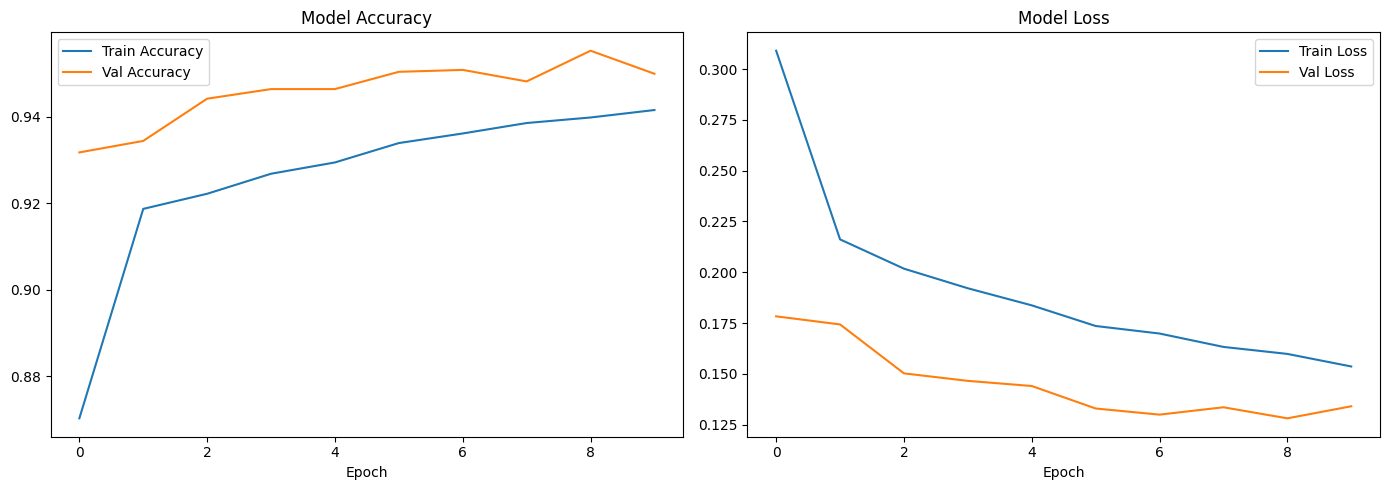

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

# Rebuild model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')


base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.00002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Fix class imbalance — penalize Organic errors less, Recyclable errors more
class_weight = {
    0: 1.0,
    1: 1.8
}

early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_waste_model_v2.keras", monitor='val_accuracy', save_best_only=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight,
    callbacks=[early_stop, checkpoint]
)

print("\nRetraining complete")

Epoch 1/15
635/635 ━━━━━━━━━━━━━━━━━━━━ 298s 441ms/step - accuracy: 0.8557 - loss: 0.4336 - val_accuracy: 0.9299 - val_loss: 0.1751
Epoch 2/15
635/635 ━━━━━━━━━━━━━━━━━━━━ 262s 412ms/step - accuracy: 0.9224 - loss: 0.2541 - val_accuracy: 0.9366 - val_loss: 0.1524
Epoch 3/15
635/635 ━━━━━━━━━━━━━━━━━━━━ 257s 405ms/step - accuracy: 0.9352 - loss: 0.2095 - val_accuracy: 0.9472 - val_loss: 0.1357
Epoch 4/15
635/635 ━━━━━━━━━━━━━━━━━━━━ 257s 405ms/step - accuracy: 0.9442 - loss: 0.1826 - val_accuracy: 0.9539 - val_loss: 0.1230
Epoch 5/15
635/635 ━━━━━━━━━━━━━━━━━━━━ 259s 409ms/step - accuracy: 0.9484 - loss: 0.1693 - val_accuracy: 0.9570 - val_loss: 0.1227
Epoch 6/15
635/635 ━━━━━━━━━━━━━━━━━━━━ 257s 405ms/step - accuracy: 0.9540 - loss: 0.1489 - val_accuracy: 0.9561 - val_loss: 0.1251
Epoch 7/15
635/635 ━━━━━━━━━━━━━━━━━━━━ 257s 405ms/step - accuracy: 0.9594 - loss: 0.1292 - val_accuracy: 0.9548 - val_loss: 0.1231
Epoch 8/15
635/635 ━━━━━━━━━━━━━━━━━━━━ 258s 406ms/step - accuracy: 0.9658 -

79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step


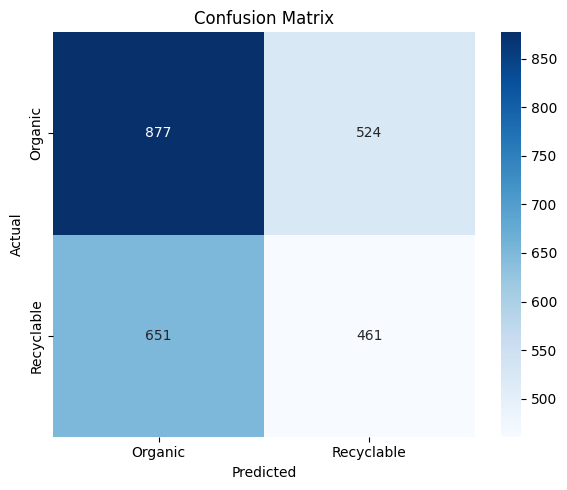


Classification Report:
              precision    recall  f1-score   support

     Organic       0.57      0.63      0.60      1401
  Recyclable       0.47      0.41      0.44      1112

    accuracy                           0.53      2513
   macro avg       0.52      0.52      0.52      2513
weighted avg       0.53      0.53      0.53      2513



In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


test_gen.reset()
preds = model.predict(test_gen)
pred_classes = (preds > 0.5).astype(int).flatten()
true_classes = test_gen.classes
class_names = ['Organic', 'Recyclable']

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


print("\nClassification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_names))

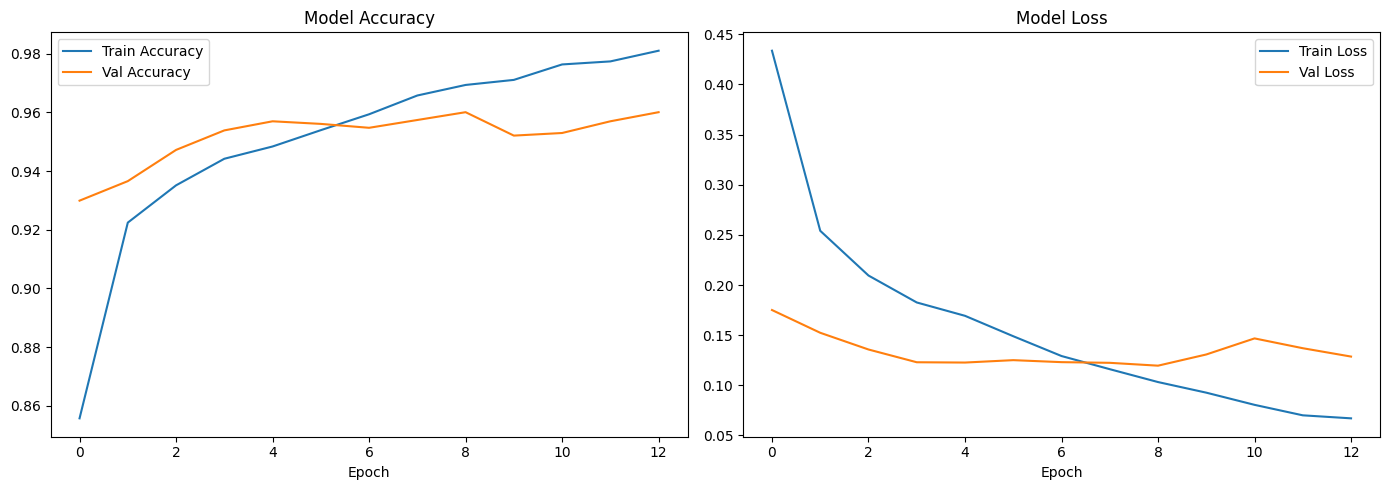

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")


model.save("waste_classifier_final.keras")
print("Model saved")

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.9208 - loss: 0.2247
Test Accuracy: 92.08%
Model saved


In [16]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 5000


material_map = {
    'Organic':   {'density': 0.95, 'drag': 0.8,  'compartment': 0},
    'HDPE':      {'density': 0.95, 'drag': 0.5,  'compartment': 1},
    'PP':        {'density': 0.91, 'drag': 0.48, 'compartment': 1},
    'PET':       {'density': 1.38, 'drag': 0.55, 'compartment': 2},
    'PVC':       {'density': 1.40, 'drag': 0.58, 'compartment': 2},
}

materials = np.random.choice(list(material_map.keys()), n)

rows = []
for mat in materials:
    props = material_map[mat]


    size_cm  = np.random.uniform(0.5, 5.0)       # cm
    mass_g   = props['density'] * (size_cm**3) * np.random.uniform(0.4, 0.8)
    moisture = np.random.uniform(0.0, 0.5) if mat == 'Organic' else np.random.uniform(0.0, 0.1)
    shape_factor = np.random.uniform(0.6, 1.0)   # 1.0 = sphere, lower = flat/irregular

    # Physics-based pressure formula
    # Heavier, denser, moist particles need more force
    # Flat shapes (low shape_factor) catch more air so need less pressure
    base_pressure = (mass_g * props['density'] * 9.81) / (shape_factor * props['drag'])
    moisture_penalty = 1 + (0.3 * moisture)
    pressure_kpa = base_pressure * moisture_penalty * np.random.uniform(0.95, 1.05)
    pressure_kpa = np.clip(pressure_kpa, 5, 150)

    pulse_ms = np.clip(mass_g * 12 * moisture_penalty, 20, 300)

    rows.append({
        'material':     mat,
        'density':      props['density'],
        'drag_coeff':   props['drag'],
        'size_cm':      round(size_cm, 3),
        'mass_g':       round(mass_g, 3),
        'moisture':     round(moisture, 3),
        'shape_factor': round(shape_factor, 3),
        'compartment':  props['compartment'],
        'pressure_kpa': round(pressure_kpa, 3),
        'pulse_ms':     round(pulse_ms, 3),
    })

df = pd.DataFrame(rows)
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nPressure range: {df.pressure_kpa.min():.1f} – {df.pressure_kpa.max():.1f} kPa")
print(f"Pulse range:    {df.pulse_ms.min():.1f} – {df.pulse_ms.max():.1f} ms")
print(f"\nMaterial counts:\n{df.material.value_counts()}")

  material  density  drag_coeff  size_cm   mass_g  moisture  shape_factor  \
0      PET     1.38        0.55    0.876    0.449     0.075         0.621   
1      PVC     1.40        0.58    2.489   11.529     0.039         0.812   
2       PP     0.91        0.48    3.074   19.089     0.076         0.662   
3      PVC     1.40        0.58    1.707    3.790     0.041         0.872   
4      PVC     1.40        0.58    0.656    0.220     0.070         0.677   
5     HDPE     0.95        0.50    1.669    3.333     0.090         0.719   
6       PP     0.91        0.48    2.351    5.867     0.067         0.930   
7       PP     0.91        0.48    4.210   37.932     0.016         0.895   
8       PP     0.91        0.48    3.521   20.185     0.008         0.997   
9      PVC     1.40        0.58    4.948  134.127     0.079         0.864   

   compartment  pressure_kpa  pulse_ms  
0            2        18.207    20.000  
1            2       150.000   139.989  
2            1       150.000 

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


le = LabelEncoder()
df['material_encoded'] = le.fit_transform(df['material'])


features = ['material_encoded', 'density', 'drag_coeff',
            'size_cm', 'mass_g', 'moisture', 'shape_factor']
targets  = ['pressure_kpa', 'pulse_ms']

X = df[features].values
y = df[targets].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


base_model_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
pressure_model = MultiOutputRegressor(base_model_reg)
pressure_model.fit(X_train_scaled, y_train)


y_pred = pressure_model.predict(X_test_scaled)

mae_pressure = mean_absolute_error(y_test[:, 0], y_pred[:, 0])
mae_pulse    = mean_absolute_error(y_test[:, 1], y_pred[:, 1])
r2_pressure  = r2_score(y_test[:, 0], y_pred[:, 0])
r2_pulse     = r2_score(y_test[:, 1], y_pred[:, 1])

print("=" * 40)
print("PRESSURE PREDICTION MODEL RESULTS")
print("=" * 40)
print(f"Pressure  → MAE: {mae_pressure:.2f} kPa  |  R²: {r2_pressure:.4f}")
print(f"Pulse     → MAE: {mae_pulse:.2f} ms   |  R²: {r2_pulse:.4f}")
print("=" * 40)

PRESSURE PREDICTION MODEL RESULTS
Pressure  → MAE: 0.92 kPa  |  R²: 0.9983
Pulse     → MAE: 0.29 ms   |  R²: 1.0000


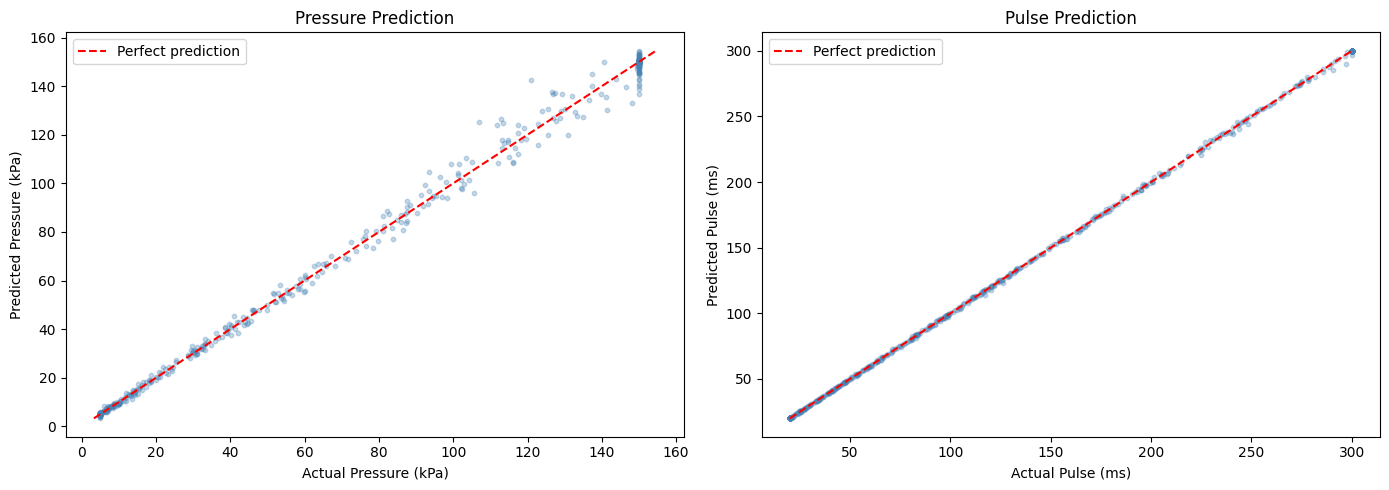

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, unit) in enumerate([('Pressure', 'kPa'), ('Pulse', 'ms')]):
    axes[i].scatter(y_test[:, i], y_pred[:, i], alpha=0.3, s=10, color='steelblue')
    min_val = min(y_test[:, i].min(), y_pred[:, i].min())
    max_val = max(y_test[:, i].max(), y_pred[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    axes[i].set_xlabel(f'Actual {label} ({unit})')
    axes[i].set_ylabel(f'Predicted {label} ({unit})')
    axes[i].set_title(f'{label} Prediction')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [19]:
import joblib

joblib.dump(pressure_model, 'pressure_model.pkl')
joblib.dump(scaler, 'pressure_scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

from google.colab import files
files.download('pressure_model.pkl')
files.download('pressure_scaler.pkl')
files.download('label_encoder.pkl')
files.download('best_waste_model_v2.keras')

print("All models saved and downloading")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All models saved and downloading
